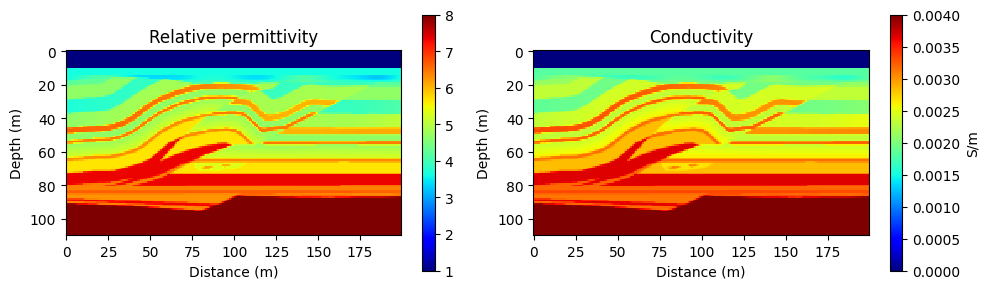

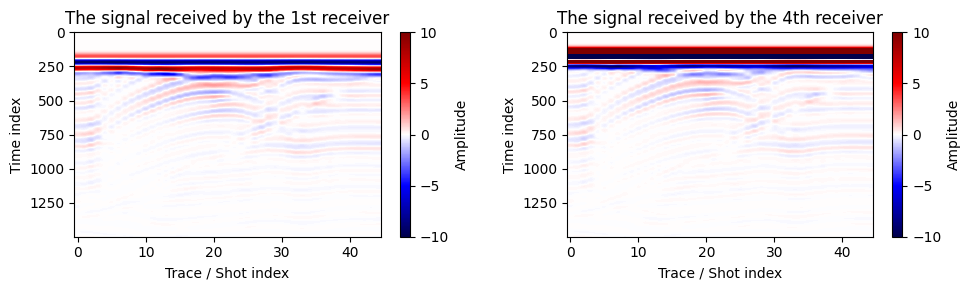

In [1]:
import DeepGPR
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage import filters
import time
import numpy as np

# Set up the parameters and models
torch.cuda.set_device(5)  # Ensure that the GPU is being used

device=torch.device("cuda")
dx=0.02
dt=2e-11
nt=1500
nshots=45

source_location=torch.zeros((nshots,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=50
source_location[:,0,1]=10
source_location[:,0,2]=torch.arange(10, 190, 4)

receiver_location = torch.zeros((nshots, 12, 3),device=device, dtype=torch.int)
receiver_location[:, :, 0] = torch.tensor([20, 25,30,35, 40,45,55, 60,65, 70,75, 80], device=device).repeat(45,1)
receiver_location[:, :, 1] = 10
receiver_location[:, :, 2] = torch.arange(11, 191, 4).repeat(12,1).transpose(0, 1)

freq=5e8
peak_time = 1 / 3e8
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)

ert=torch.tensor(np.load('OverThrust.npy')[::2,::2], dtype=torch.float32, device=device).repeat(100,1,1)
ert = torch.cat([torch.ones(ert.shape[0], 10, ert.shape[2], device=ert.device, dtype=ert.dtype),ert], dim=1)
set=ert.clone()*0.0005
ert[:,:11,:]= 1
set[:,:11,:]= 0

fig, axes = plt.subplots(1, 2, figsize=(10, 3))  
im1 = axes[0].imshow(ert[50, :, :].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal')
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')
im2 = axes[1].imshow(set[50, :, :].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')
plt.tight_layout()
plt.show()

pershot=1
#Forward modeling
r_obs_list = []
for i in range(nshots//pershot):
    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location[i*pershot:(i+1)*pershot,:,:], 
        receiver_location=receiver_location[i*pershot:(i+1)*pershot,:,:], 
        er=ert, se=set,model_gradient_sampling_interval=3
    )
    r_obs_list.append(r[-1])
r_obs = torch.cat(r_obs_list, dim=0)


fig, axes = plt.subplots(1, 2, figsize=(10, 3))
im0 = axes[0].imshow(
    r_obs[:, :, 3].detach().cpu().numpy().T,
    cmap='seismic',
    origin='upper',
    aspect='auto',
    vmax=10,
    vmin=-10
)
axes[0].set_title("The signal received by the 1st receiver")
axes[0].set_xlabel("Trace / Shot index")
axes[0].set_ylabel("Time index")
fig.colorbar(im0, ax=axes[0], label='Amplitude')
im1 = axes[1].imshow(
    r_obs[:, :, 5].detach().cpu().numpy().T,
    cmap='seismic',
    origin='upper',
    aspect='auto',
    vmax=10,
    vmin=-10
)
axes[1].set_title("The signal received by the 4th receiver")
axes[1].set_xlabel("Trace / Shot index")
axes[1].set_ylabel("Time index")
fig.colorbar(im1, ax=axes[1], label='Amplitude')
plt.tight_layout()
plt.show()



In [2]:
er=torch.tensor(filters.gaussian(ert.detach().cpu().numpy(),sigma=10),device=device)
er[:,:20,:]=ert[:,:20,:]
se=torch.tensor(filters.gaussian(set.detach().cpu().numpy(),sigma=10),device=device)
se[:,:20,:]=set[:,:20,:]

er.requires_grad_()

optimizer1 = torch.optim.Adam([
    {'params': er, 'lr': 0.1},
])
optimizer=optimizer1

optimizer2 = torch.optim.Adam([
    {'params': er, 'lr': 0.05},{'params': se, 'lr': 0.2}
])

losses = []
n_epochs=111

loss_fnmse = torch.nn.MSELoss()
loss_fnl1= torch.nn.L1Loss()

start_time = time.time()
tv_criterion = DeepGPR.TVRegularization(weight_ep=20,weight_sigma=0.0001).to(device)

Epoch 0, Loss Data: 67838.88, TV_er: 3482379.00, Time: 65.51s


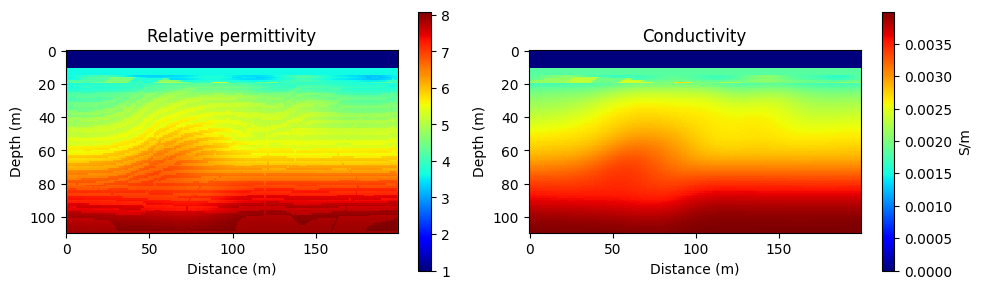

Epoch 1, Loss Data: 37346.88, TV_er: 6283679.00, Time: 64.84s
Epoch 2, Loss Data: 23864.62, TV_er: 7019992.50, Time: 65.24s
Epoch 3, Loss Data: 17551.91, TV_er: 8110054.00, Time: 65.15s
Epoch 4, Loss Data: 13983.69, TV_er: 8579334.00, Time: 65.11s
Epoch 5, Loss Data: 11779.75, TV_er: 8796178.00, Time: 64.82s


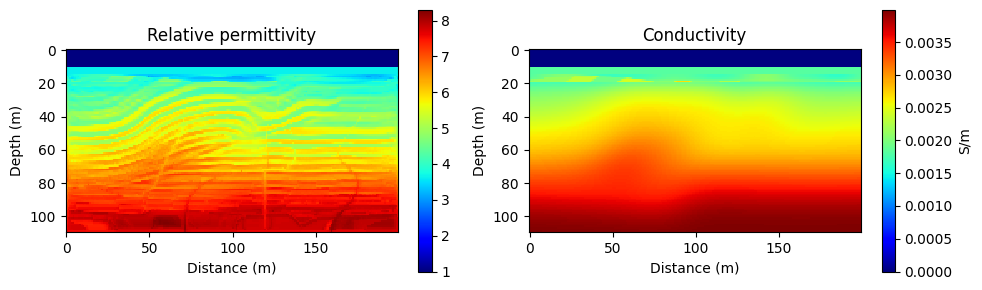

Epoch 6, Loss Data: 10522.19, TV_er: 9030779.00, Time: 64.81s
Epoch 7, Loss Data: 9846.14, TV_er: 9224909.00, Time: 64.71s
Epoch 8, Loss Data: 9321.39, TV_er: 9327506.00, Time: 64.93s
Epoch 9, Loss Data: 8676.05, TV_er: 9346561.00, Time: 64.87s
Epoch 10, Loss Data: 7877.90, TV_er: 9320322.00, Time: 65.04s


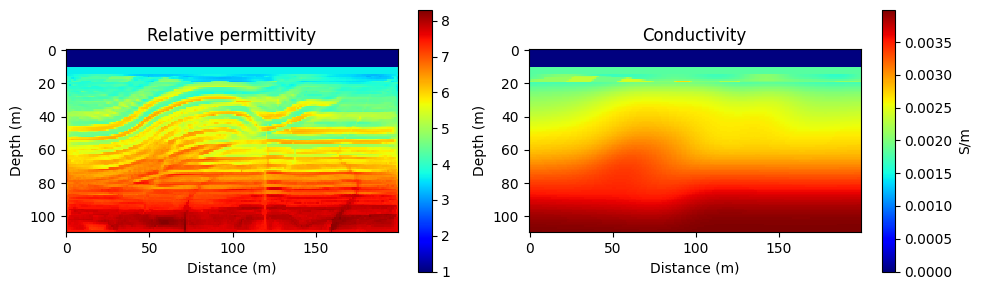

Epoch 11, Loss Data: 7025.98, TV_er: 9290209.00, Time: 64.79s
Epoch 12, Loss Data: 6227.30, TV_er: 9274384.00, Time: 65.07s
Epoch 13, Loss Data: 5540.60, TV_er: 9270959.00, Time: 64.96s
Epoch 14, Loss Data: 4980.31, TV_er: 9268710.00, Time: 65.07s
Epoch 15, Loss Data: 4530.84, TV_er: 9253993.00, Time: 65.06s


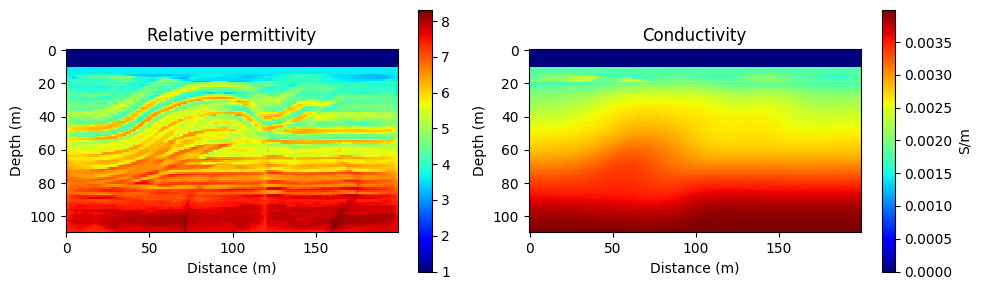

Epoch 16, Loss Data: 4159.38, TV_er: 9216236.00, Time: 65.04s
Epoch 17, Loss Data: 3834.08, TV_er: 9148649.00, Time: 65.02s
Epoch 18, Loss Data: 3534.95, TV_er: 9054651.00, Time: 65.18s
Epoch 19, Loss Data: 3254.20, TV_er: 8944488.00, Time: 65.14s
Epoch 20, Loss Data: 2991.16, TV_er: 8832341.00, Time: 65.09s


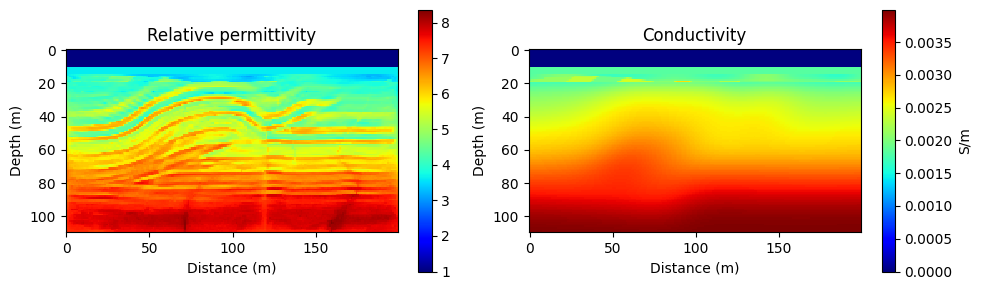

In [ ]:
import torch
import math
import time
import matplotlib.pyplot as plt
import torch.nn.functional as F

air_depth = 15          
taper_transition = 5   


taper = torch.ones_like(se)
taper[:, :air_depth, :] = 0.0
for z in range(taper_transition):
    weight = math.sin(math.pi * z / (2 * taper_transition))
    taper[:, air_depth + z, :] = weight
Nz = se.shape[1]  
se_taper = taper.clone()
power_factor = 1.3

for z in range(air_depth, Nz):
    depth_ratio = (z - air_depth) / (Nz - air_depth - 1) 
    depth_weight = depth_ratio ** power_factor
    se_taper[:, z, :] = se_taper[:, z, :] * depth_weight

tv_ratio_er = 0.1
tv_ratio_se = 0.08  

for epoch in range(n_epochs):
    epoch_start = time.time()

    if epoch > 50:
        optimizer = optimizer2
        se.requires_grad_()

    optimizer.zero_grad()
    epoch_loss = 0.0  
    r_pred_list = []
    
    for i in range(nshots // pershot):
        r = DeepGPR.compute(
            device=device, dx=dx, dt=dt, 
            source_amplitudes=source_amplitudes,
            source_location=source_location[i*pershot:(i+1)*pershot, :, :], 
            receiver_location=receiver_location[i*pershot:(i+1)*pershot, :, :], 
            er=er, se=se, model_gradient_sampling_interval=2
        )
        r_pred_list.append(r[-1])
        loss = loss_fnmse(r[-1], r_obs[i*pershot:(i+1)*pershot, :, :]) * 1e4
        loss.backward()  
        epoch_loss += loss.item()
        
    r_pred = torch.cat(r_pred_list, dim=0)

    if er.requires_grad:
        er.grad = er.grad * taper  
        grad_data_er = er.grad.clone() 
        norm_data_er = torch.norm(grad_data_er) + 1e-8
        
    if se.requires_grad:
        se.grad = se.grad * se_taper  
        grad_data_se = se.grad.clone()
        norm_data_se = torch.norm(grad_data_se) + 1e-8

    optimizer.zero_grad()  
    
    losstv_er = tv_criterion(ep=er, sigma=None)
    
    if se.requires_grad:
        losstv_se = tv_criterion(ep=None, sigma=se)
        losstv = losstv_er + losstv_se
    else:
        losstv_se = torch.tensor(0.0)
        losstv = losstv_er
        
    losstv.backward()

    if er.requires_grad:
        er.grad = er.grad * taper
        norm_tv_er = torch.norm(er.grad) + 1e-8
        weight_tv_er = (norm_data_er / norm_tv_er) * tv_ratio_er
        er.grad = grad_data_er + er.grad * weight_tv_er

    if se.requires_grad:
        if se.grad is None:
            se.grad = grad_data_se
        else:
            se.grad = se.grad * se_taper 
            norm_tv_se = torch.norm(se.grad) + 1e-8
            weight_tv_se = (norm_data_se / norm_tv_se) * tv_ratio_se
            se.grad = grad_data_se + se.grad * weight_tv_se

    optimizer.step()
    
    losses.append(epoch_loss + losstv.item()) 
    
    epoch_time = time.time() - epoch_start  
    total_time = time.time() - start_time  
    
    with torch.no_grad():
        if er.requires_grad:
            er.data.clamp_(min=1)
        if se.requires_grad:
            se.data.clamp_(min=0)
        
    if se.requires_grad:
        print(f"Epoch {epoch}, Loss Data: {epoch_loss:.2f}, TV_er: {losstv_er.item():.2f}, TV_se: {losstv_se.item():.2f}, Time: {epoch_time:.2f}s")
    else:
        print(f"Epoch {epoch}, Loss Data: {epoch_loss:.2f}, TV_er: {losstv_er.item():.2f}, Time: {epoch_time:.2f}s")
    
    if epoch % 5 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))  
        im1 = axes[0].imshow(er[50,:,:].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal')
        cbar1 = plt.colorbar(im1, ax=axes[0])
        axes[0].set_title('Relative permittivity')
        axes[0].set_xlabel('Distance (m)')
        axes[0].set_ylabel('Depth (m)')

        im2 = axes[1].imshow(se[50,:,:].detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal')
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('S/m')
        axes[1].set_title('Conductivity')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Depth (m)')
        plt.tight_layout()
        plt.show()

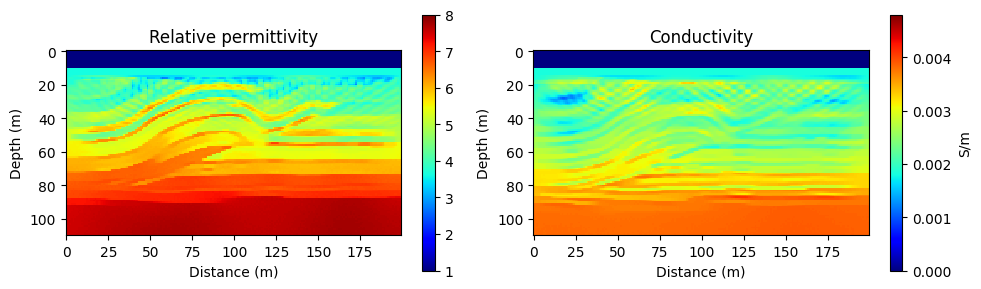

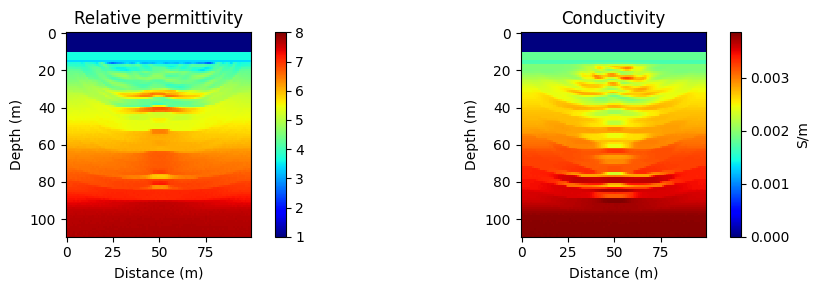

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))  
im1 = axes[0].imshow(er[40,:,:].detach().cpu().numpy(),
                    cmap='jet',
                    interpolation='nearest',
                    aspect='equal', vmax=ert.max(), vmin=ert.min())
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(se[40,:,:].detach().cpu().numpy(),
                    cmap='jet',
                    interpolation='nearest',
                    aspect='equal', vmax=set.max()*1.2, vmin=set.min())
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(10, 3))  
im1 = axes[0].imshow(er[:,:,50].detach().cpu().numpy().T,
                    cmap='jet',
                    interpolation='nearest',
                    aspect='equal', vmax=ert.max(), vmin=ert.min())
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(se[:,:,50].detach().cpu().numpy().T,
                    cmap='jet',
                    interpolation='nearest',
                    aspect='equal')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')
plt.tight_layout()
plt.show()